In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      validation_curve)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, classification_report)
from sklearn.preprocessing import LabelEncoder

# Plot Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'axes.titleweight': 'bold'})
RANDOM_STATE = 42
COLORS = {'dt_full': '#E53935', 'dt_pruned': '#1E88E5', 'rf': '#43A047'}
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [8]:
def load_heart_disease():
    """Load Heart Disease dataset from URL or generate synthetic data."""
    # Try URL first (works with internet)
    urls = [
        "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv",
        "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv",
    ]
    for url in urls:
        try:
            df = pd.read_csv(url)
            if 'target' in df.columns and len(df) > 100:
                print(f"✓ Heart Disease loaded from URL ({df.shape[0]} rows)")
                return df, 'Heart Disease (UCI Cleveland)'
        except Exception:
            pass
    
    # Try OpenML
    try:
        from sklearn.datasets import fetch_openml
        data = fetch_openml('heart-statlog', version=1, as_frame=True, parser='auto')
        df = data.frame.copy()
        le = LabelEncoder()
        df['target'] = le.fit_transform(df['class'].astype(str))
        df.drop('class', axis=1, inplace=True)
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        print(f"✓ Heart Disease loaded from OpenML ({df.shape[0]} rows)")
        return df, 'Heart Statlog (OpenML)'
    except Exception:
        pass

    # Synthetic fallback
    print("⚠ Using synthetic Heart Disease dataset (internet unavailable)...")
    np.random.seed(RANDOM_STATE)
    n = 303
    age = np.random.normal(54, 9, n).clip(29, 77).astype(int)
    sex = np.random.binomial(1, 0.68, n)
    cp  = np.random.choice([0,1,2,3], n, p=[0.47,0.17,0.28,0.08])
    trestbps = np.random.normal(131, 17, n).clip(94, 200).astype(int)
    chol     = np.random.normal(246, 52, n).clip(126, 564).astype(int)
    fbs      = np.random.binomial(1, 0.15, n)
    restecg  = np.random.choice([0,1,2], n, p=[0.50,0.01,0.49])
    thalach  = np.random.normal(150, 23, n).clip(71, 202).astype(int)
    exang    = np.random.binomial(1, 0.33, n)
    oldpeak  = np.random.exponential(1.0, n).clip(0, 6.2).round(1)
    slope    = np.random.choice([0,1,2], n, p=[0.08,0.46,0.46])
    ca       = np.random.choice([0,1,2,3], n, p=[0.58,0.22,0.13,0.07])
    thal     = np.random.choice([1,2,3], n, p=[0.05,0.55,0.40])
    risk = (0.04*(age-50) + 0.3*sex + 0.4*(cp==0).astype(int)
            - 0.02*(thalach-150) + 0.5*exang + 0.3*oldpeak
            + 0.3*ca + 0.2*(thal==3).astype(int)
            + np.random.normal(0, 0.3, n))
    target = (risk > np.median(risk)).astype(int)
    df = pd.DataFrame({'age':age,'sex':sex,'cp':cp,'trestbps':trestbps,
                       'chol':chol,'fbs':fbs,'restecg':restecg,'thalach':thalach,
                       'exang':exang,'oldpeak':oldpeak,'slope':slope,'ca':ca,
                       'thal':thal,'target':target})
    print(f"✓ Synthetic Heart Disease generated ({df.shape[0]} rows)")
    return df, 'Heart Disease (Synthetic)'

df, dataset_name = load_heart_disease()

# Preprocessing
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
df = df.apply(pd.to_numeric, errors='coerce').dropna()

X = df.drop(columns=['target'])
y = df['target'].astype(int)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"\nDataset  : {dataset_name}")
print(f"Shape    : {df.shape}  |  Features: {len(feature_names)}")
print(f"Train    : {len(X_train)}  |  Test: {len(X_test)}")
print(f"Classes  : {dict(y.value_counts())}")
df.head()

✓ Heart Disease loaded from URL (303 rows)

Dataset  : Heart Disease (UCI Cleveland)
Shape    : (303, 14)  |  Features: 13
Train    : 242  |  Test: 61
Classes  : {1: np.int64(165), 0: np.int64(138)}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


  Depth   : 8
  Leaves  : 42
  Train Accuracy : 1.0000  ← Memorized!
  Test  Accuracy : 0.7049  ← Generalization
  Overfit Gap    : 0.2951
  F1 Score       : 0.7429
  AUC-ROC        : 0.6975


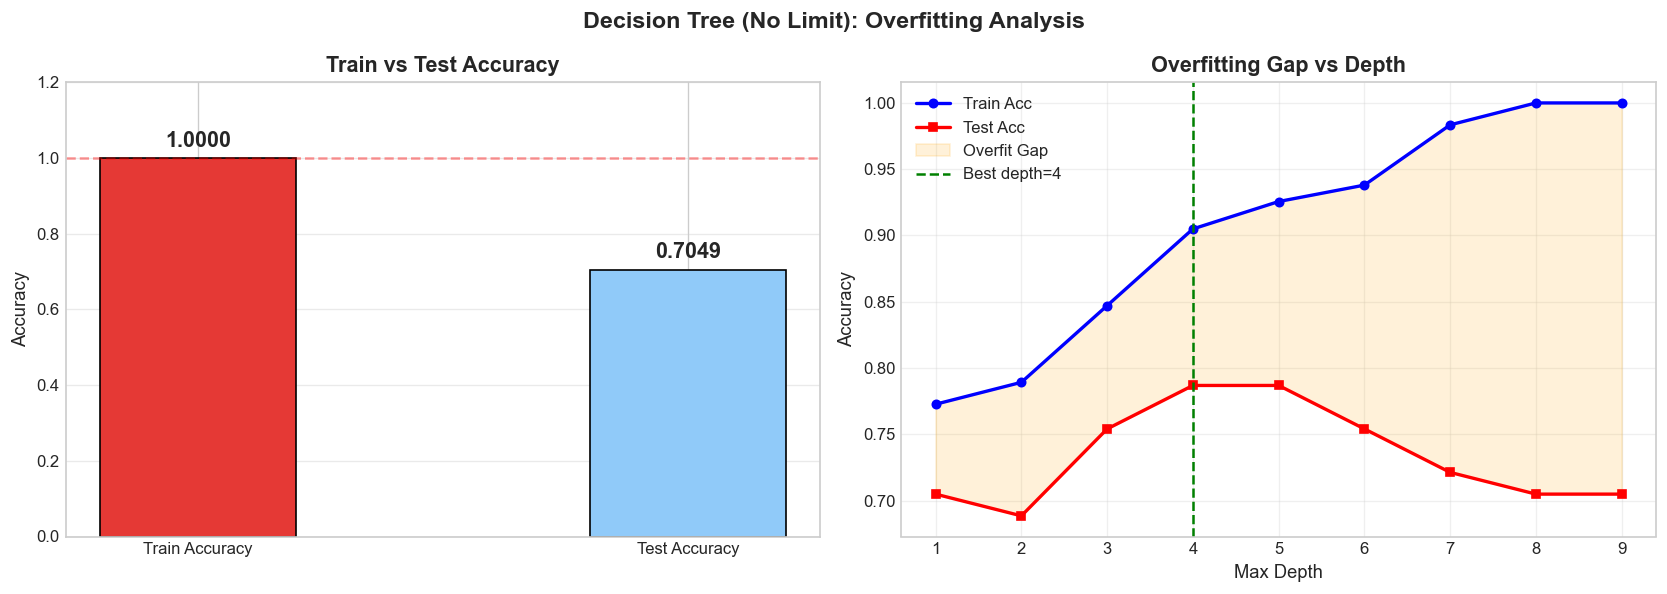

In [9]:
# Train unpruned Decision Tree
dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_full.fit(X_train, y_train)

dt_full_train_acc = accuracy_score(y_train, dt_full.predict(X_train))
dt_full_test_acc  = accuracy_score(y_test,  dt_full.predict(X_test))
dt_full_f1        = f1_score(y_test, dt_full.predict(X_test), zero_division=0)
dt_full_auc       = roc_auc_score(y_test, dt_full.predict_proba(X_test)[:,1])

print("=" * 55)
print(f"  Depth   : {dt_full.get_depth()}")
print(f"  Leaves  : {dt_full.get_n_leaves()}")
print(f"  Train Accuracy : {dt_full_train_acc:.4f}  ← Memorized!")
print(f"  Test  Accuracy : {dt_full_test_acc:.4f}  ← Generalization")
print(f"  Overfit Gap    : {dt_full_train_acc - dt_full_test_acc:.4f}")
print(f"  F1 Score       : {dt_full_f1:.4f}")
print(f"  AUC-ROC        : {dt_full_auc:.4f}")
print("=" * 55)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Tree (No Limit): Overfitting Analysis', fontsize=14, fontweight='bold')

# Bar chart
ax = axes[0]
vals = [dt_full_train_acc, dt_full_test_acc]
bars = ax.bar(['Train Accuracy', 'Test Accuracy'], vals,
               color=[COLORS['dt_full'], '#90CAF9'], edgecolor='black', width=0.4)
ax.set_ylim(0, 1.2)
ax.set_title('Train vs Test Accuracy')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)
ax.axhline(1.0, color='red', ls='--', alpha=0.4)
ax.grid(axis='y', alpha=0.4)

# Depth vs Accuracy
ax2 = axes[1]
depth_range = range(1, min(22, dt_full.get_depth() + 2))
tr_accs, te_accs = [], []
for d in depth_range:
    tmp = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tmp.fit(X_train, y_train)
    tr_accs.append(accuracy_score(y_train, tmp.predict(X_train)))
    te_accs.append(accuracy_score(y_test,  tmp.predict(X_test)))
ax2.plot(list(depth_range), tr_accs, 'b-o', ms=5, lw=2, label='Train Acc')
ax2.plot(list(depth_range), te_accs, 'r-s', ms=5, lw=2, label='Test Acc')
ax2.fill_between(list(depth_range), te_accs, tr_accs, alpha=0.15, color='orange', label='Overfit Gap')
ax2.axvline(list(depth_range)[np.argmax(te_accs)], color='green', ls='--', lw=1.5,
            label=f'Best depth={list(depth_range)[np.argmax(te_accs)]}')
ax2.set_xlabel('Max Depth'); ax2.set_ylabel('Accuracy')
ax2.set_title('Overfitting Gap vs Depth'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/01_overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

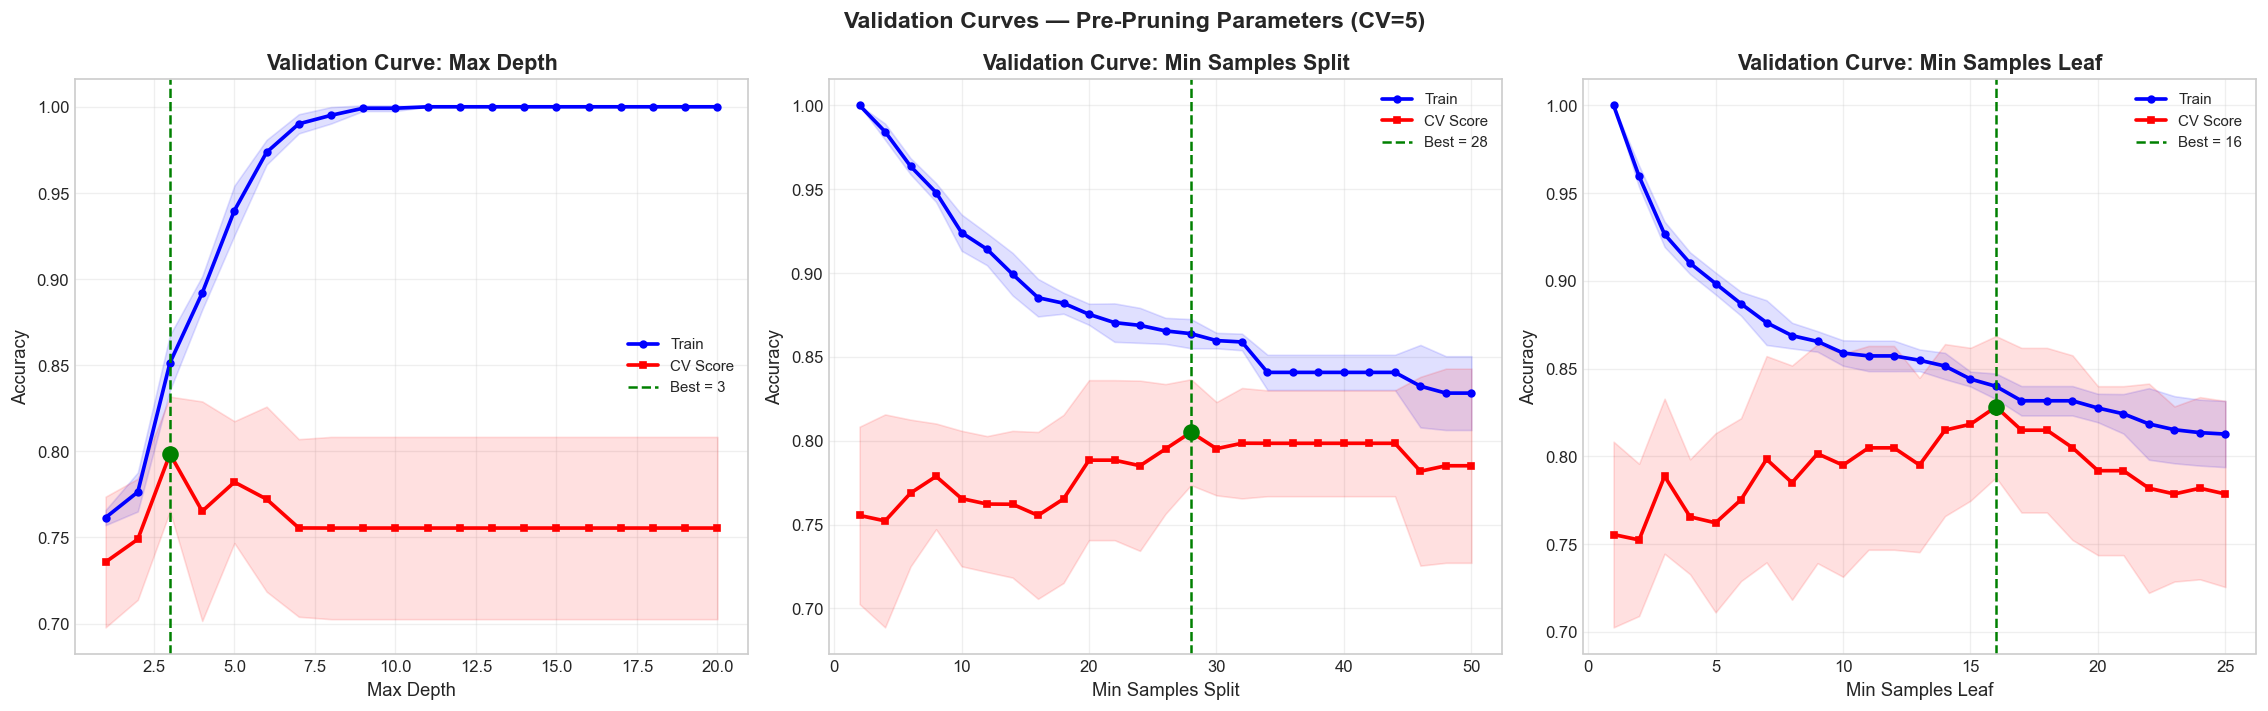

Best values from curves: {'max_depth': 3, 'min_samples_split': 28, 'min_samples_leaf': 16}


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Validation Curves — Pre-Pruning Parameters (CV=5)', fontsize=14, fontweight='bold')

params_config = [
    ('max_depth',         range(1, 21),    'Max Depth'),
    ('min_samples_split', range(2, 52, 2), 'Min Samples Split'),
    ('min_samples_leaf',  range(1, 26),    'Min Samples Leaf'),
]
best_vals = {}

for ax, (pname, p_range, plabel) in zip(axes, params_config):
    pr = list(p_range)
    tr_sc, cv_sc = validation_curve(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        X, y, param_name=pname, param_range=pr,
        cv=5, scoring='accuracy', n_jobs=-1
    )
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    cv_m, cv_s = cv_sc.mean(1), cv_sc.std(1)
    best_idx   = np.argmax(cv_m)
    best_vals[pname] = pr[best_idx]

    ax.plot(pr, tr_m, 'b-o', ms=4, lw=2.2, label='Train')
    ax.fill_between(pr, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='blue')
    ax.plot(pr, cv_m, 'r-s', ms=4, lw=2.2, label='CV Score')
    ax.fill_between(pr, cv_m-cv_s, cv_m+cv_s, alpha=0.12, color='red')
    ax.axvline(pr[best_idx], ls='--', lw=1.5, color='green',
               label=f'Best = {pr[best_idx]}')
    ax.scatter([pr[best_idx]], [cv_m[best_idx]], color='green', zorder=6, s=80)
    ax.set_xlabel(plabel); ax.set_ylabel('Accuracy')
    ax.set_title(f'Validation Curve: {plabel}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Best values from curves:", best_vals)

In [11]:
param_grid = {
    'max_depth':          [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split':  [2, 5, 10, 20, 30],
    'min_samples_leaf':   [1, 2, 4, 6, 8],
}

grid_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, refit=True
)
grid_cv.fit(X_train, y_train)

best_dt     = grid_cv.best_estimator_
best_params = grid_cv.best_params_

dt_best_train_acc = accuracy_score(y_train, best_dt.predict(X_train))
dt_best_test_acc  = accuracy_score(y_test,  best_dt.predict(X_test))
dt_best_f1        = f1_score(y_test, best_dt.predict(X_test), zero_division=0)
dt_best_auc       = roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1])

print("=" * 55)
print(f"  Best CV Score : {grid_cv.best_score_:.4f}")
print(f"  Best Params   : {best_params}")
print(f"  Depth Before  : {dt_full.get_depth()}  →  After: {best_dt.get_depth()}")
print(f"  Leaves Before : {dt_full.get_n_leaves()} →  After: {best_dt.get_n_leaves()}")
print(f"  Train Acc     : {dt_best_train_acc:.4f}")
print(f"  Test Acc      : {dt_best_test_acc:.4f}  (+{dt_best_test_acc-dt_full_test_acc:.4f} vs unpruned)")
print(f"  F1 Score      : {dt_best_f1:.4f}")
print(f"  AUC-ROC       : {dt_best_auc:.4f}")
print("=" * 55)

  Best CV Score : 0.7977
  Best Params   : {'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 2}
  Depth Before  : 8  →  After: 3
  Leaves Before : 42 →  After: 8
  Train Acc     : 0.8430
  Test Acc      : 0.7541  (+0.0492 vs unpruned)
  F1 Score      : 0.7826
  AUC-ROC       : 0.8193


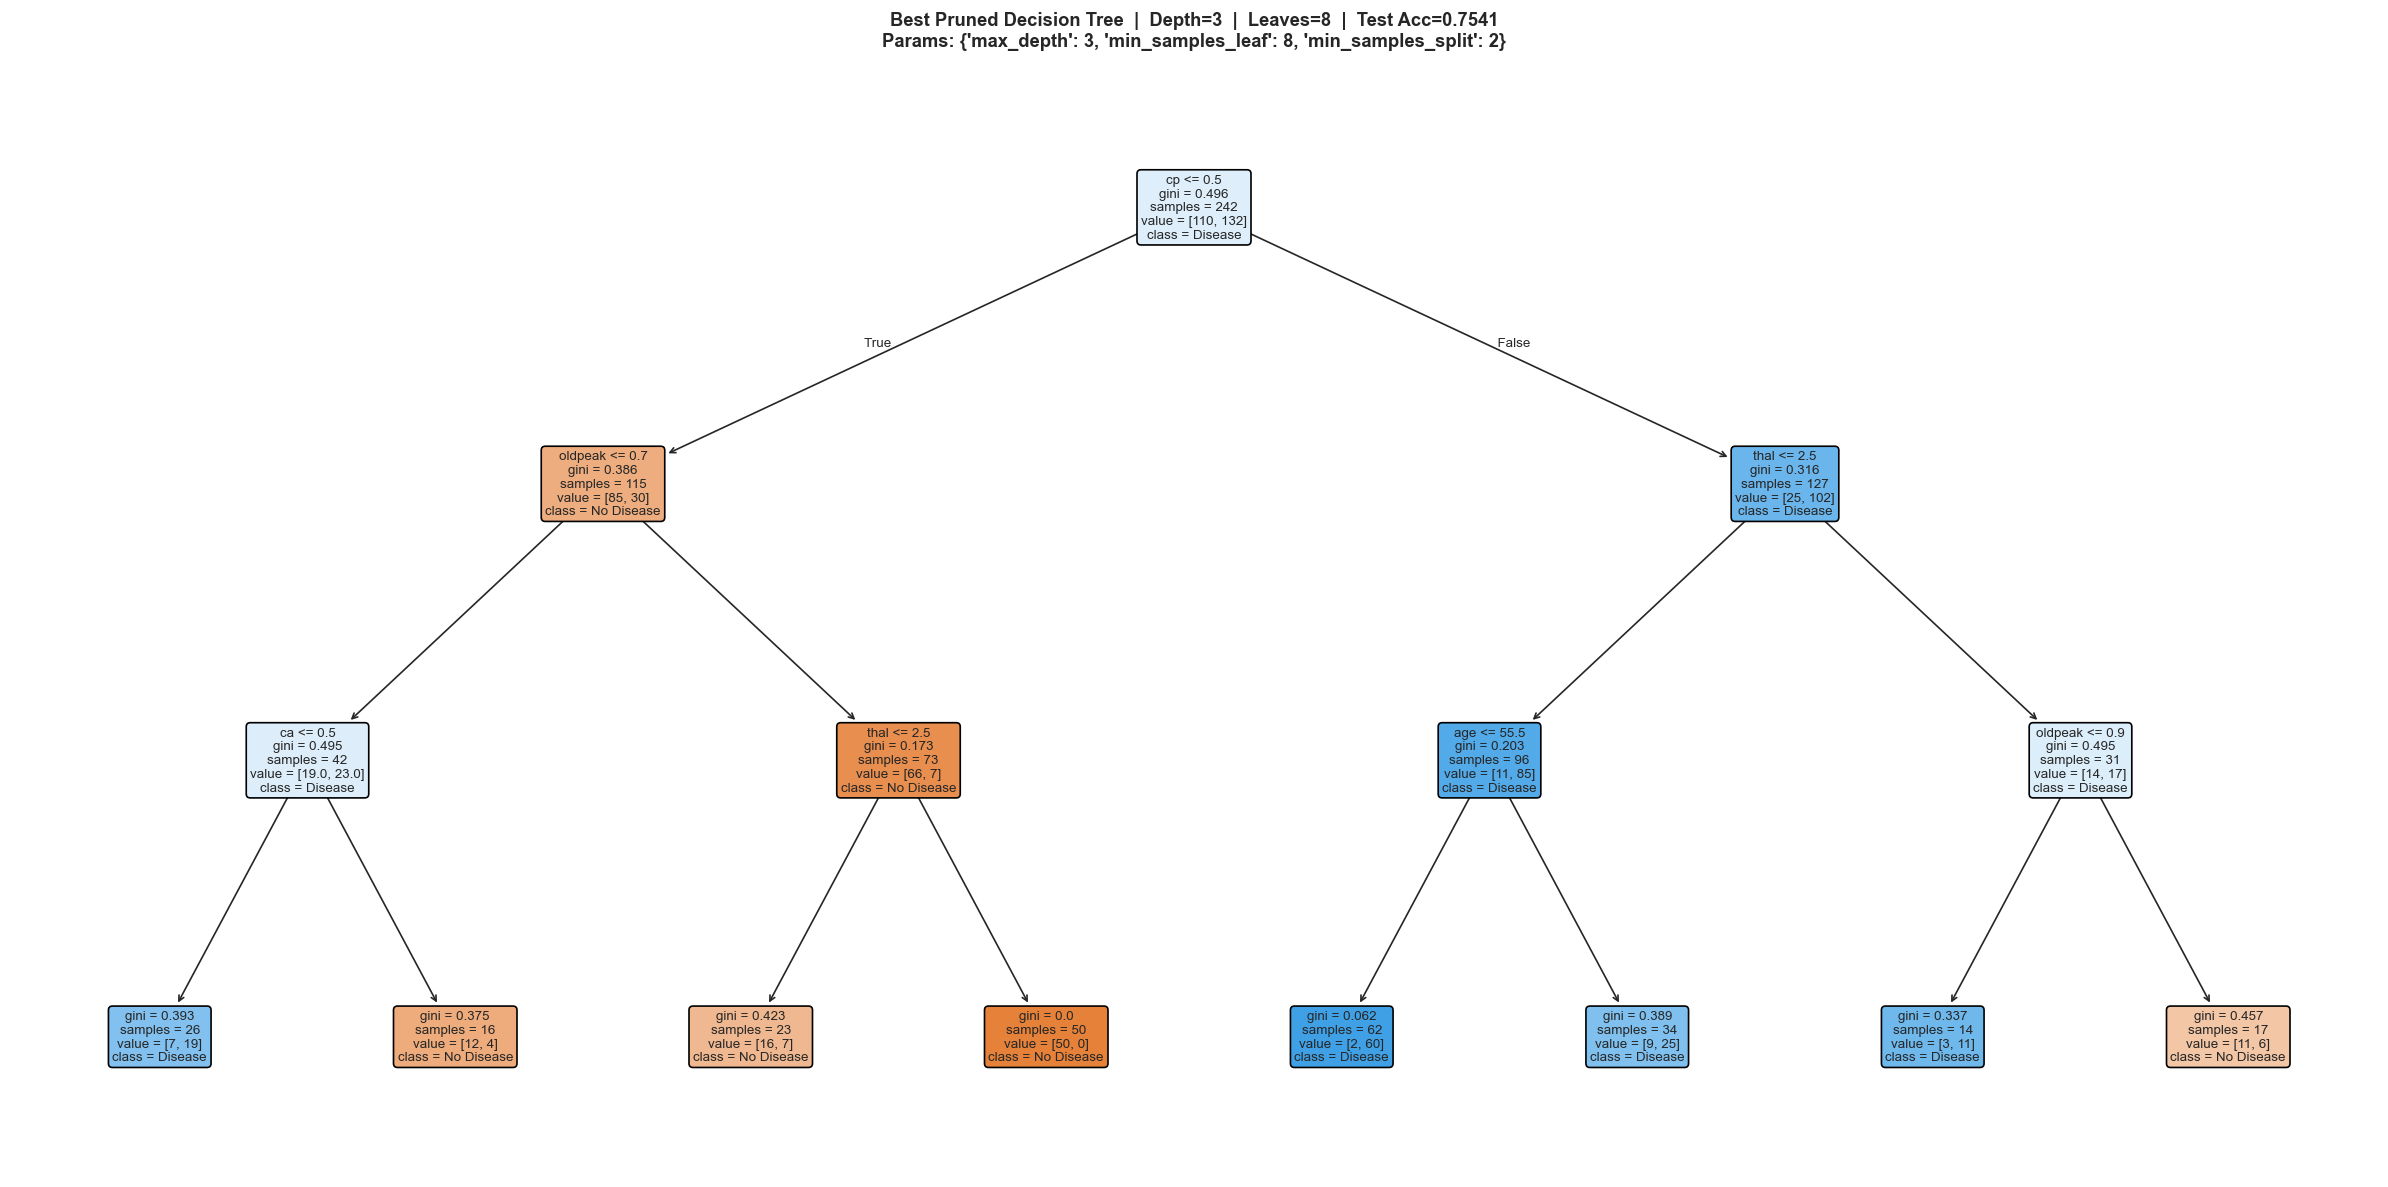

In [12]:
tree_depth = best_dt.get_depth()
fw = min(34, max(20, tree_depth * 5))
fh = min(18, max(10, tree_depth * 2.5))

fig, ax = plt.subplots(figsize=(fw, fh))
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    filled=True, rounded=True, ax=ax, max_depth=5,
    fontsize=8, impurity=True, proportion=False
)
ax.set_title(
    f'Best Pruned Decision Tree  |  Depth={tree_depth}  |  '
    f'Leaves={best_dt.get_n_leaves()}  |  Test Acc={dt_best_test_acc:.4f}\n'
    f'Params: {best_params}',
    fontsize=11, fontweight='bold', pad=14
)
plt.tight_layout()
plt.savefig('outputs/03_best_tree_plot.png', dpi=110, bbox_inches='tight')
plt.show()

  RANDOM FOREST (100 Trees)
  Train Acc  : 1.0000
  Test Acc   : 0.8361
  F1 Score   : 0.8649
  AUC-ROC    : 0.9161
  OOB Score  : 0.8099
  OOB Error  : 0.1901  (19.01%)


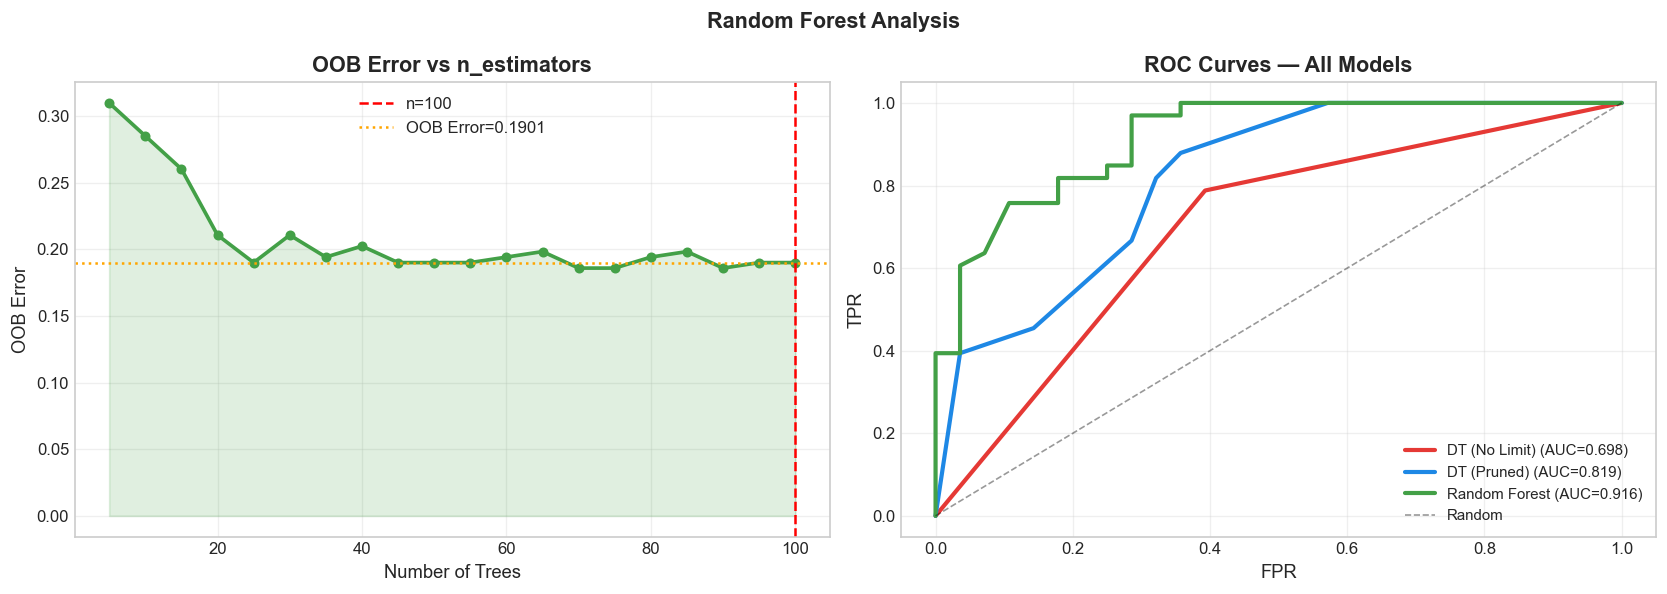

In [13]:
rf = RandomForestClassifier(
    n_estimators=100, oob_score=True,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf.predict(X_test))
rf_f1        = f1_score(y_test, rf.predict(X_test), zero_division=0)
rf_auc       = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
rf_oob_score = rf.oob_score_
rf_oob_error = 1 - rf_oob_score

print("=" * 55)
print("  RANDOM FOREST (100 Trees)")
print(f"  Train Acc  : {rf_train_acc:.4f}")
print(f"  Test Acc   : {rf_test_acc:.4f}")
print(f"  F1 Score   : {rf_f1:.4f}")
print(f"  AUC-ROC    : {rf_auc:.4f}")
print(f"  OOB Score  : {rf_oob_score:.4f}")
print(f"  OOB Error  : {rf_oob_error:.4f}  ({rf_oob_error*100:.2f}%)")
print("=" * 55)

# OOB Error Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest Analysis', fontsize=13, fontweight='bold')

n_range = list(range(5, 105, 5))
oob_errors = []
for n in n_range:
    tmp = RandomForestClassifier(n_estimators=n, oob_score=True,
                                  random_state=RANDOM_STATE, n_jobs=-1)
    tmp.fit(X_train, y_train)
    oob_errors.append(1 - tmp.oob_score_)

ax1 = axes[0]
ax1.plot(n_range, oob_errors, 'g-o', ms=5, lw=2.2, color=COLORS['rf'])
ax1.fill_between(n_range, oob_errors, alpha=0.12, color='green')
ax1.axvline(100, color='red', ls='--', lw=1.5, label='n=100')
ax1.axhline(rf_oob_error, color='orange', ls=':', lw=1.5,
            label=f'OOB Error={rf_oob_error:.4f}')
ax1.set_xlabel('Number of Trees'); ax1.set_ylabel('OOB Error')
ax1.set_title('OOB Error vs n_estimators'); ax1.legend(); ax1.grid(alpha=0.3)

# ROC Curves
ax2 = axes[1]
for model, name, color in [(dt_full, 'DT (No Limit)', COLORS['dt_full']),
                             (best_dt, 'DT (Pruned)',   COLORS['dt_pruned']),
                             (rf,      'Random Forest', COLORS['rf'])]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    ax2.plot(fpr, tpr, lw=2.5, color=color, label=f'{name} (AUC={auc:.3f})')
ax2.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('ROC Curves — All Models'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/04_rf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

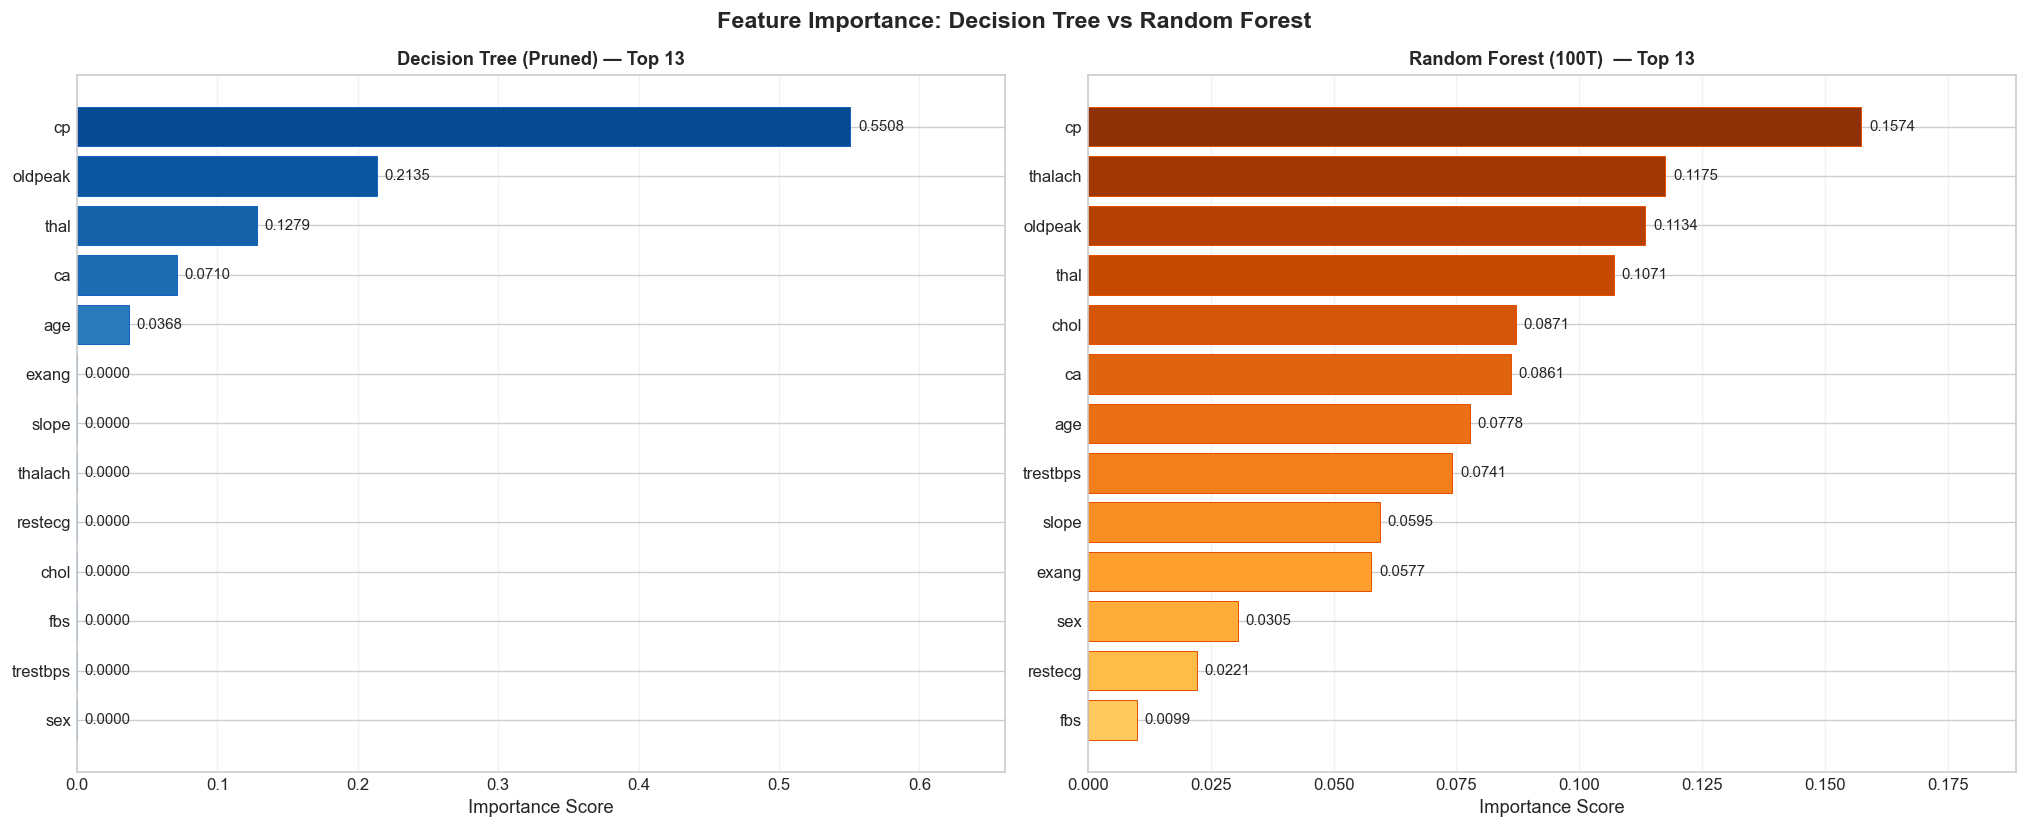

Top 5 DT features: {'cp': 0.5507762888342731, 'oldpeak': 0.21346338474339485, 'thal': 0.1278904233566244, 'ca': 0.07104919633693065, 'age': 0.03682070672877697}
Top 5 RF features: {'cp': 0.15739173079046803, 'thalach': 0.11749102165787942, 'oldpeak': 0.11339892054219698, 'thal': 0.10706190764739959, 'chol': 0.08713060707926566}


In [14]:
n_top = min(13, len(feature_names))
dt_imp = pd.Series(best_dt.feature_importances_, index=feature_names).sort_values(ascending=True).tail(n_top)
rf_imp = pd.Series(rf.feature_importances_,      index=feature_names).sort_values(ascending=True).tail(n_top)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Feature Importance: Decision Tree vs Random Forest', fontsize=14, fontweight='bold')

for ax, imp, title, cmap_name, edge_c in [
    (axes[0], dt_imp, f'Decision Tree (Pruned) — Top {n_top}', 'Blues',  '#1565C0'),
    (axes[1], rf_imp, f'Random Forest (100T)  — Top {n_top}',  'YlOrBr', '#E65100'),
]:
    cmap = plt.get_cmap(cmap_name)
    clrs = cmap(np.linspace(0.35, 0.9, len(imp)))
    bars = ax.barh(imp.index, imp.values, color=clrs, edgecolor=edge_c, linewidth=0.6)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.25)
    for bar, v in zip(bars, imp.values):
        ax.text(v + max(imp.values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, max(imp.values)*1.2)

plt.tight_layout()
plt.savefig('outputs/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 DT features:", dt_imp.iloc[::-1][:5].to_dict())
print("Top 5 RF features:", rf_imp.iloc[::-1][:5].to_dict())

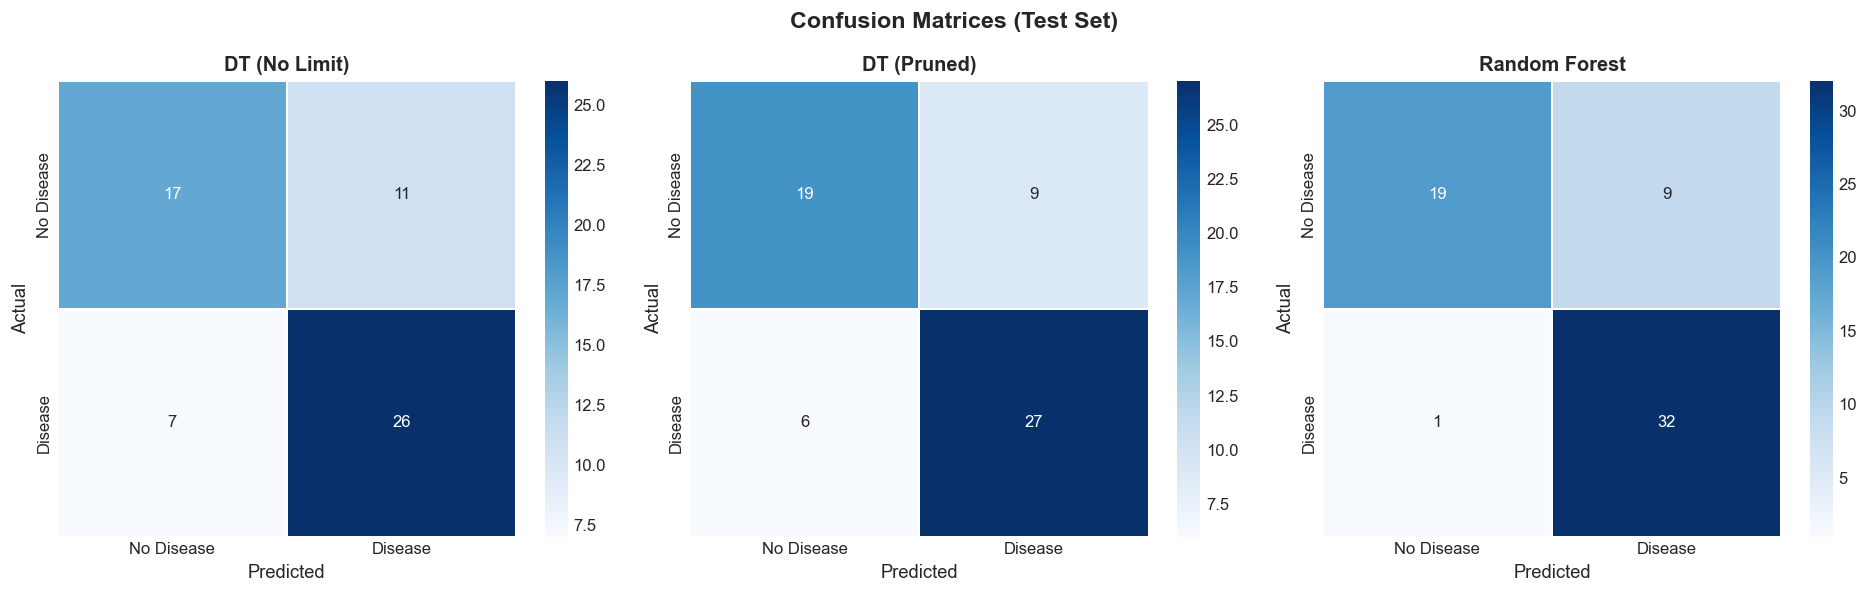

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=14, fontweight='bold')

for ax, model, name in [
    (axes[0], dt_full,  'DT (No Limit)'),
    (axes[1], best_dt,  'DT (Pruned)'),
    (axes[2], rf,       'Random Forest'),
]:
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1, linecolor='white')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/06_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

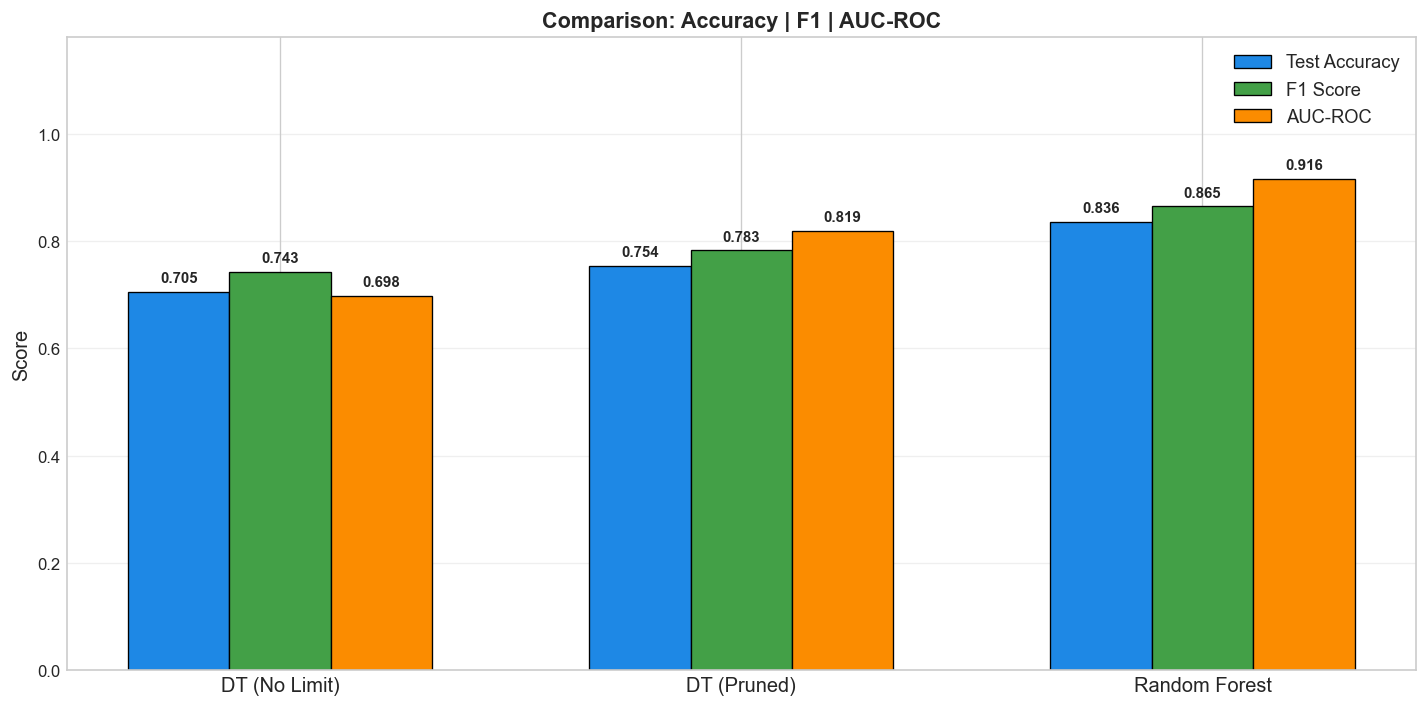

In [16]:
# Metrics comparison chart
models_names = ['DT (No Limit)', 'DT (Pruned)', 'Random Forest']
acc_vals  = [dt_full_test_acc, dt_best_test_acc, rf_test_acc]
f1_vals   = [dt_full_f1,       dt_best_f1,       rf_f1]
auc_vals  = [dt_full_auc,      dt_best_auc,      rf_auc]

x = np.arange(3); w = 0.22
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x-w, acc_vals, w, label='Test Accuracy', color='#1E88E5', edgecolor='black', lw=0.8)
b2 = ax.bar(x,   f1_vals,  w, label='F1 Score',      color='#43A047', edgecolor='black', lw=0.8)
b3 = ax.bar(x+w, auc_vals, w, label='AUC-ROC',       color='#FB8C00', edgecolor='black', lw=0.8)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h+0.012, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models_names, fontsize=12)
ax.set_ylim(0, 1.18); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparison: Accuracy | F1 | AUC-ROC', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/07_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Summary Table
summary = pd.DataFrame({
    'Model': ['DT (No Depth Limit)', 'DT (Pruned — GridSearchCV)', 'Random Forest (100 Trees)'],
    'Train Accuracy':  [f'{dt_full_train_acc:.4f}', f'{dt_best_train_acc:.4f}', f'{rf_train_acc:.4f}'],
    'Test Accuracy':   [f'{dt_full_test_acc:.4f}',  f'{dt_best_test_acc:.4f}',  f'{rf_test_acc:.4f}'],
    'F1 Score':        [f'{dt_full_f1:.4f}',        f'{dt_best_f1:.4f}',        f'{rf_f1:.4f}'],
    'AUC-ROC':         [f'{dt_full_auc:.4f}',       f'{dt_best_auc:.4f}',       f'{rf_auc:.4f}'],
    'OOB Error':       ['N/A',                       'N/A',                       f'{rf_oob_error:.4f}'],
    'Tree Depth':      [str(dt_full.get_depth()),    str(best_dt.get_depth()),    'N/A (Ensemble)'],
    'Leaves':          [str(dt_full.get_n_leaves()), str(best_dt.get_n_leaves()), '100 trees'],
})

print("=" * 80)
print("  FINAL SUMMARY TABLE — Tree Models Lab")
print("=" * 80)
print(summary.to_string(index=False))
print()
print(f"[Key Insights]")
print(f"  → Overfitting gap (DT Full): {dt_full_train_acc - dt_full_test_acc:.4f}")
print(f"  → Pre-pruning improvement  : +{dt_best_test_acc - dt_full_test_acc:.4f} (test acc)")
print(f"  → RF vs Pruned DT (AUC)    : +{rf_auc - dt_best_auc:.4f}")
print(f"  → OOB Error (RF)           : {rf_oob_error:.4f} ({rf_oob_error*100:.2f}%)")
print(f"  → 🏆 Winner: Random Forest — highest AUC ({rf_auc:.4f})")
summary.to_csv('outputs/summary_table.csv', index=False)
print()
print("✅ All outputs saved to outputs/ folder!")
print("📊 Launch dashboard: streamlit run app.py")
summary

  FINAL SUMMARY TABLE — Tree Models Lab
                     Model Train Accuracy Test Accuracy F1 Score AUC-ROC OOB Error     Tree Depth    Leaves
       DT (No Depth Limit)         1.0000        0.7049   0.7429  0.6975       N/A              8        42
DT (Pruned — GridSearchCV)         0.8430        0.7541   0.7826  0.8193       N/A              3         8
 Random Forest (100 Trees)         1.0000        0.8361   0.8649  0.9161    0.1901 N/A (Ensemble) 100 trees

[Key Insights]
  → Overfitting gap (DT Full): 0.2951
  → Pre-pruning improvement  : +0.0492 (test acc)
  → RF vs Pruned DT (AUC)    : +0.0969
  → OOB Error (RF)           : 0.1901 (19.01%)
  → 🏆 Winner: Random Forest — highest AUC (0.9161)

✅ All outputs saved to outputs/ folder!
📊 Launch dashboard: streamlit run app.py


,Model,Train Accuracy,Test Accuracy,F1 Score,AUC-ROC,OOB Error,Tree Depth,Leaves
0,DT (No Depth Limit),1.0000,0.7049,0.7429,0.6975,N/A,8,42
1,DT (Pruned — GridSearchCV),0.8430,0.7541,0.7826,0.8193,N/A,3,8
2,Random Forest (100 Trees),1.0000,0.8361,0.8649,0.9161,0.1901,N/A (Ensemble),100 trees
